# Baseline Analysis

Evaluates the **simple baseline** (AdamW + Muon, default hyperparameters) over **3 seeds** (42, 123, 1337).

Metrics reported:
- `val_bpb` — bits-per-byte on the FineWeb validation split (primary challenge metric)
- `val_loss` — token cross-entropy
- `quant_file_bytes` — size of the int8+zlib compressed model artifact

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import wandb
from utils import apply_style, get_deep_palette

apply_style()
PALETTE = get_deep_palette()

ENTITY  = "the-golfers"
PROJECT = "ml_ai_project"
BASELINE_PREFIX = "golf_baseline_antonio_new"

api = wandb.Api()

## Fetch baseline runs from W&B

In [12]:
runs = api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{BASELINE_PREFIX}"}},
)

rows = []
for run in runs:
    summary = run.summary._json_dict
    config  = run.config
    rows.append({
        "run_name":               run.name,
        "seed":                   config.get("seed"),
        "final_val_bpb":          summary.get("final_val_bpb"),
        "final_val_loss":         summary.get("final_val_loss"),
        "quant_file_bytes":       summary.get("quant_file_bytes"),
        "quant_compression_ratio": summary.get("quant_compression_ratio"),
        "quant_param_count":      summary.get("quant_param_count"),
        "quant_baseline_bytes":   summary.get("quant_baseline_bytes"),
        "quant_int8_payload_bytes": summary.get("quant_int8_payload_bytes"),
    })

df = pd.DataFrame(rows).sort_values("seed").reset_index(drop=True)
df

,run_name,seed,final_val_bpb,final_val_loss,quant_file_bytes,quant_compression_ratio,quant_param_count,quant_baseline_bytes,quant_int8_payload_bytes
0,golf_baseline_antonio_new_seed42,42,1.311341,2.214144,15777299,3.911253,17059912,67191072,17178912
1,golf_baseline_antonio_new_seed123,123,1.309026,2.210235,15783532,3.911253,17059912,67191072,17178912
2,golf_baseline_antonio_new_seed1337,1337,1.310237,2.212280,15770704,3.911253,17059912,67191072,17178912


## Summary statistics

In [13]:
mean_bpb   = df["final_val_bpb"].mean()
std_bpb    = df["final_val_bpb"].std()
mean_loss  = df["final_val_loss"].mean()
std_loss   = df["final_val_loss"].std()
mean_bytes = df["quant_file_bytes"].mean() / 1e6
std_bytes  = df["quant_file_bytes"].std()  / 1e6

print("=" * 55)
print(f"BASELINE RESULTS  ({len(df)} seeds)")
print("=" * 55)
print(df[["seed", "final_val_bpb", "final_val_loss", "quant_file_bytes"]].to_string(index=False))
print()
print(f"final_val_bpb  :  {mean_bpb:.4f} \u00b1 {std_bpb:.4f}")
print(f"final_val_loss :  {mean_loss:.4f} \u00b1 {std_loss:.4f}")
print(f"quant_file_MB  :  {mean_bytes:.2f} \u00b1 {std_bytes:.2f} MB")
print("=" * 55)

BASELINE RESULTS  (3 seeds)
 seed  final_val_bpb  final_val_loss  quant_file_bytes
   42       1.311341        2.214144          15777299
  123       1.309026        2.210235          15783532
 1337       1.310237        2.212280          15770704

final_val_bpb  :  1.3102 ± 0.0012
final_val_loss :  2.2122 ± 0.0020
quant_file_MB  :  15.78 ± 0.01 MB


## Final metrics per seed — bar charts

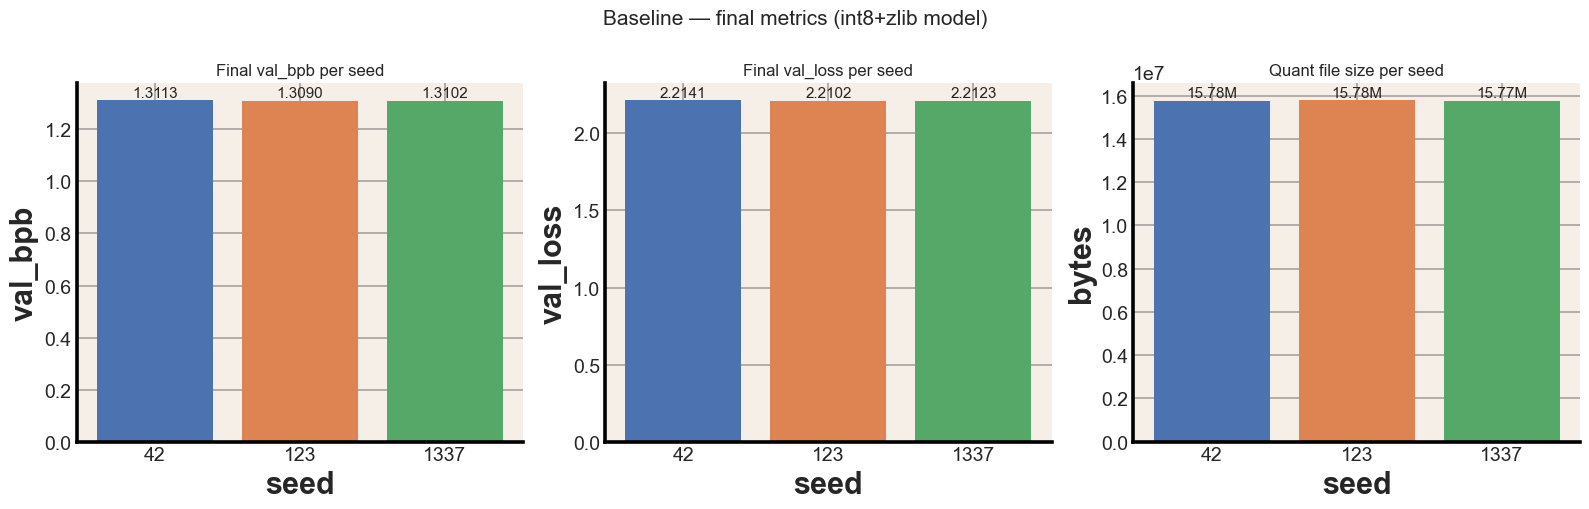

In [14]:
seeds_str = df["seed"].astype(str)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, ylabel, title in [
    (axes[0], "final_val_bpb",    "val_bpb",    "Final val_bpb per seed"),
    (axes[1], "final_val_loss",   "val_loss",   "Final val_loss per seed"),
    (axes[2], "quant_file_bytes", "bytes",      "Quant file size per seed"),
]:
    bars = ax.bar(seeds_str, df[col], color=PALETTE[:len(df)])
    ax.set_xlabel("seed")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    for bar, val in zip(bars, df[col]):
        label = f"{val:.4f}" if col != "quant_file_bytes" else f"{val/1e6:.2f}M"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.002,
            label, ha="center", va="bottom", fontsize=11,
        )

plt.suptitle("Baseline — final metrics (int8+zlib model)", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## Learning curves

Fetches per-step `val_bpb` and `train_loss` histories for all baseline seeds.

In [15]:
def fetch_history(prefix, metric):
    runs = api.runs(
        f"{ENTITY}/{PROJECT}",
        filters={"display_name": {"$regex": f"^{prefix}"}},
    )
    out = {}
    for run in runs:
        hist = run.history(keys=["_step", metric], pandas=True)
        if not hist.empty:
            hist = hist.rename(columns={"_step": "step"}).dropna()
            seed = run.config.get("seed", run.name)
            out[seed] = hist
    return dict(sorted(out.items()))

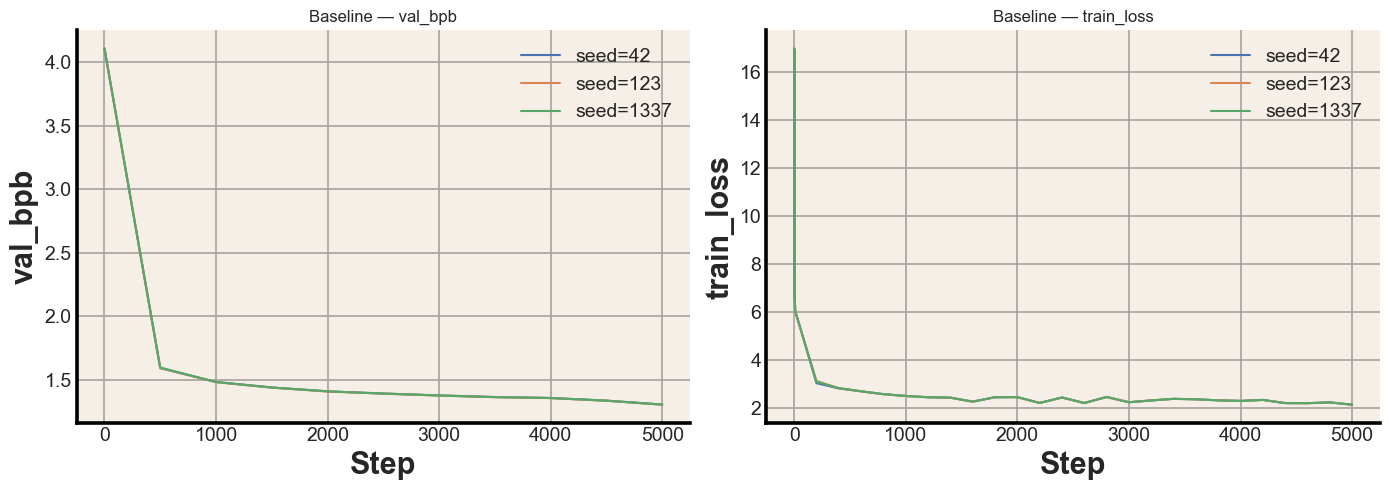

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (metric, ax, title) in [
    ("val_bpb",    axes[0], "val_bpb"),
    ("train_loss", axes[1], "train_loss"),
]:
    for (seed, hist), color in zip(fetch_history(BASELINE_PREFIX, metric).items(), PALETTE):
        ax.plot(hist["step"], hist[metric], label=f"seed={seed}", color=color)
    ax.set_xlabel("Step")
    ax.set_ylabel(metric)
    ax.set_title(f"Baseline \u2014 {title}")
    ax.legend()

plt.tight_layout()
plt.show()

## LR schedule

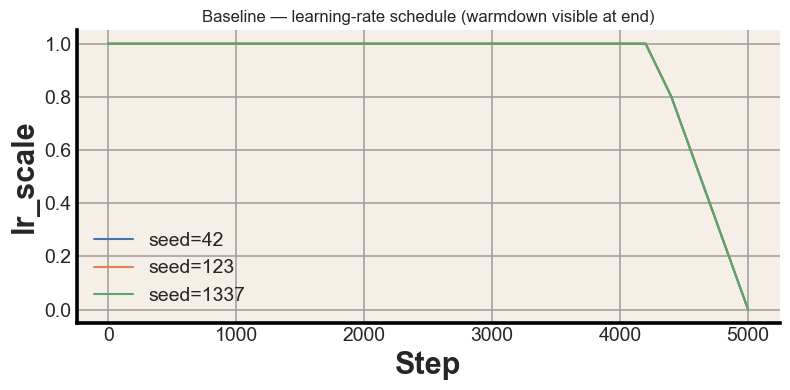

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))

for (seed, hist), color in zip(fetch_history(BASELINE_PREFIX, "lr_scale").items(), PALETTE):
    ax.plot(hist["step"], hist["lr_scale"], label=f"seed={seed}", color=color)

ax.set_xlabel("Step")
ax.set_ylabel("lr_scale")
ax.set_title("Baseline \u2014 learning-rate schedule (warmdown visible at end)")
ax.legend()
plt.tight_layout()
plt.show()

## Model / quantization stats

In [18]:
df_stats = df.copy()
df_stats["quant_baseline_MB"] = df_stats["quant_baseline_bytes"]     / 1e6
df_stats["quant_payload_MB"]  = df_stats["quant_int8_payload_bytes"] / 1e6
df_stats["quant_file_MB"]     = df_stats["quant_file_bytes"]         / 1e6

display_cols = [
    "seed", "quant_param_count",
    "quant_baseline_MB", "quant_payload_MB", "quant_file_MB",
    "quant_compression_ratio",
]
print(df_stats[display_cols].to_string(index=False, float_format="{:.2f}".format))

 seed  quant_param_count  quant_baseline_MB  quant_payload_MB  quant_file_MB  quant_compression_ratio
   42           17059912              67.19             17.18          15.78                     3.91
  123           17059912              67.19             17.18          15.78                     3.91
 1337           17059912              67.19             17.18          15.77                     3.91


### Model size breakdown (baseline \u2192 int8 payload \u2192 zlib file)

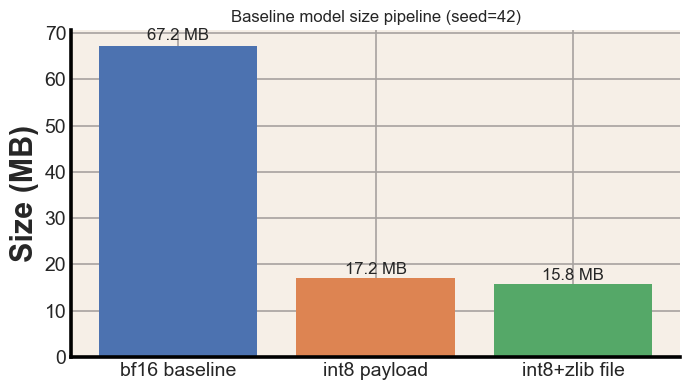

In [19]:
rep = df.iloc[0]

labels = ["bf16 baseline", "int8 payload", "int8+zlib file"]
values = [
    rep["quant_baseline_bytes"]     / 1e6,
    rep["quant_int8_payload_bytes"] / 1e6,
    rep["quant_file_bytes"]         / 1e6,
]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, values, color=PALETTE[:3])
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.01,
        f"{val:.1f} MB", ha="center", va="bottom", fontsize=12,
    )
ax.set_ylabel("Size (MB)")
ax.set_title(f"Baseline model size pipeline (seed={rep['seed']})")
plt.tight_layout()
plt.show()

## Variance across seeds

Small variance confirms that ablations need only a single seed.

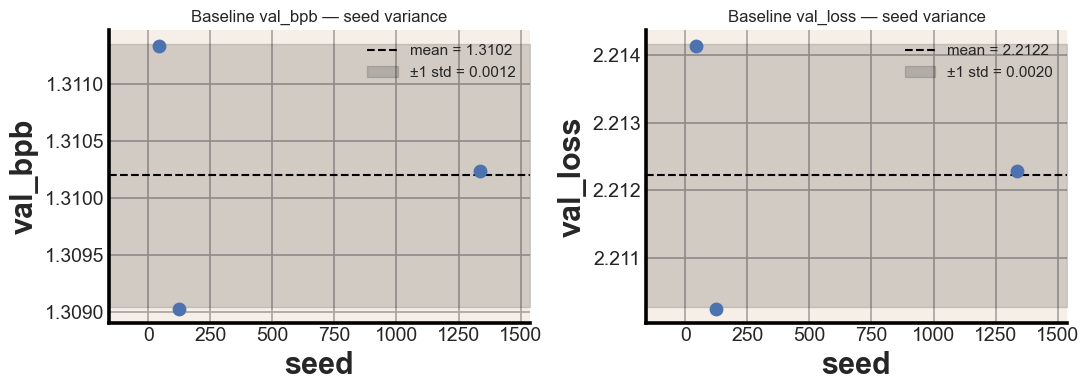

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col, ylabel in [
    (axes[0], "final_val_bpb",  "val_bpb"),
    (axes[1], "final_val_loss", "val_loss"),
]:
    mean_val = df[col].mean()
    std_val  = df[col].std()
    x_min, x_max = df["seed"].min() - 200, df["seed"].max() + 200
    ax.scatter(df["seed"], df[col], color=PALETTE[0], zorder=5, s=80)
    ax.axhline(mean_val, color="black", linestyle="--", linewidth=1.5,
               label=f"mean = {mean_val:.4f}")
    ax.fill_between(
        [x_min, x_max],
        mean_val - std_val, mean_val + std_val,
        alpha=0.15, color="black", label=f"\u00b11 std = {std_val:.4f}",
    )
    ax.set_xlabel("seed")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Baseline {ylabel} \u2014 seed variance")
    ax.legend(fontsize=11)
    ax.set_xlim(x_min, x_max)

plt.tight_layout()
plt.show()